# GiBUU Interaction Model Training

This notebook trains the `GiBUUInteractionModel` (Encoder-Decoder Transformer) for predicting particle changes during interactions.

**Workflow:**
1. Load processed NPZ data from `GiBUU_dataprep.ipynb`
2. Prepare data for training (call `prepare_interaction_data`)
3. Configure model and training parameters
4. Train model with PyTorch Lightning
5. Test trained model

**Model Architecture:**
- Encoder-Decoder Transformer architecture
- Encoder processes input timestep (t1)
- Decoder generates output timestep (t2) with teacher forcing
- Bidirectional attention (particles in same timestep can attend to each other)
- Predicts particle types and features

**Output:**
- Trained model saved in `lightning_logs/`
- Checkpoints for resuming training or inference

## Step 1: Imports

In [19]:
# Enable auto-reload of modules
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import lightning.pytorch as pl
import numpy as np
import glob
from pathlib import Path
from typing import List, Tuple, Dict

# Import from gibuu_transformer package
from gibuu_transformer import (
    GiBUUInteractionModel,
    GiBUUInteractionLightning,
    gibuu_interaction_loss,
    prepare_interaction_data,
    load_pairs_from_npz,
    FEATS_MEAN,
    FEATS_SIGMA,
    EOS_STEP_TOKEN,
    PAD_TOKEN,
    START_TOKEN,
    list_checkpoints,
    find_checkpoint
)

print(f"✓ Imports successful!")
print(f"  PyTorch version: {torch.__version__}")
print(f"  Lightning version: {pl.__version__}")
print(f"  Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"\nFeature normalization constants loaded:")
print(f"  FEATS_MEAN: {FEATS_MEAN}")
print(f"  FEATS_SIGMA: {FEATS_SIGMA}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Imports successful!
  PyTorch version: 2.8.0+cu128
  Lightning version: 2.5.2
  Device: cuda

Feature normalization constants loaded:
  FEATS_MEAN: [0.0, 0.0, 6.13, 0.42, 0.0, 0.0, 0.5]
  FEATS_SIGMA: [5.89, 5.89, 9.33, 0.975, 0.304, 0.304, 1.123]


## Step 2: Load NPZ Data

Load preprocessed data from `GiBUU_dataprep.ipynb` output.

In [20]:
# Configuration
NPZ_PATH = "./processed_data"
JOB_ID = 990
MAX_PAIRS = None  # Set to a number for quick testing, None to load all

# Load interaction pairs (pairs with changes)
with_file = Path(NPZ_PATH) / "npz_with_changes" / f"pairs_with_changes_{JOB_ID:06d}.npz"

with_changes_files = [str(with_file)] if with_file.exists() else []

print(f"Loading Job {JOB_ID:06d}...")
print(f"  Interaction file: {with_file.name} {'✓' if with_file.exists() else '✗'}")

# Load pairs with changes (interactions)
pairs_with_changes = load_pairs_from_npz(with_changes_files, max_pairs=MAX_PAIRS, random_subset=True)

print(f"\n✓ Data loaded: {len(pairs_with_changes)} interaction pairs")
if MAX_PAIRS is not None:
    print(f"  (Limited to {MAX_PAIRS} pairs for quick testing)")

Loading Job 000990...
  Interaction file: pairs_with_changes_000990.npz ✗

✓ Data loaded: 0 interaction pairs
  (Limited to 100 pairs for quick testing)


## Step 3: Prepare Data for Training

Convert pairs to format expected by the interaction model (encoder-decoder).

In [4]:
# Prepare interaction data
interaction_data = prepare_interaction_data(
    pairs_with_changes,  # Pass as positional argument
    stats_path=None  # Uses constants from constants.py
)

print("✓ Data prepared for training:")
print(f"  Total pairs: {len(interaction_data['input_encoded_ids'])}")

# Show example
idx = 0
print(f"\nExample pair {idx}:")
print(f"  Input IDs: {interaction_data['input_encoded_ids'][idx][:5]}... ({len(interaction_data['input_encoded_ids'][idx])} particles)")
print(f"  Output IDs: {interaction_data['output_encoded_ids'][idx][:5]}... ({len(interaction_data['output_encoded_ids'][idx])} particles)")

Preparing 147408 interaction pairs for training...
✓ Prepared 147408 interaction pairs
  Features: [x, y, z, KE, Px, Py, Pz] where KE = E - m
  Normalization: (feature - FEATS_MEAN) / FEATS_SIGMA
✓ Data prepared for training:
  Total pairs: 147408

Example pair 0:
  Input IDs: [1153, 1125, 1024]... (3 particles)
  Output IDs: [2048, 1153, 1026, 1024]... (4 particles)


## Step 4: Create Dataset and DataLoader

In [5]:
class TimeStepPairDataset(Dataset):
    """
    Dataset for time step pairs with variable-length sequences.
    """
    def __init__(self, pair_data):
        self.input_encoded_ids = pair_data['input_encoded_ids']
        self.input_particle_feats = pair_data['input_particle_feats']
        self.output_encoded_ids = pair_data['output_encoded_ids']
        self.output_particle_feats = pair_data['output_particle_feats']
    
    def __len__(self):
        return len(self.input_encoded_ids)
    
    def __getitem__(self, idx):
        return {
            'input_encoded_ids': self.input_encoded_ids[idx],
            'input_particle_feats': self.input_particle_feats[idx],
            'output_encoded_ids': self.output_encoded_ids[idx],
            'output_particle_feats': self.output_particle_feats[idx]
        }

def collate_timestep_pairs(batch):
    """
    Custom collate function for variable-length time step pairs.
    Pads each batch to the maximum length within that batch.
    """
    # Extract all sequences from batch
    input_ids_list = [item['input_encoded_ids'] for item in batch]
    input_feats_list = [item['input_particle_feats'] for item in batch]
    output_ids_list = [item['output_encoded_ids'] for item in batch]
    output_feats_list = [item['output_particle_feats'] for item in batch]
    
    # Find max lengths in this batch
    max_input_len = max(len(ids) for ids in input_ids_list)
    max_output_len = max(len(ids) for ids in output_ids_list)
    max_seq_len = max(max_input_len, max_output_len)
    
    batch_size = len(batch)
    
    # Pad input sequences
    input_encoded_ids_padded = []
    input_particle_feats_padded = []
    input_padding_mask_list = []
    
    for ids, feats in zip(input_ids_list, input_feats_list):
        pad_len = max_seq_len - len(ids)
        if pad_len > 0:
            ids_padded = ids + [PAD_TOKEN] * pad_len
            feats_padded = feats + [[0.0] * 7] * pad_len
            padding_mask = [False] * len(ids) + [True] * pad_len
        else:
            ids_padded = ids
            feats_padded = feats
            padding_mask = [False] * len(ids)
        
        input_encoded_ids_padded.append(ids_padded)
        input_particle_feats_padded.append(feats_padded)
        input_padding_mask_list.append(padding_mask)
    
    # Pad output sequences
    output_encoded_ids_padded = []
    output_particle_feats_padded = []
    output_padding_mask_list = []
    
    for ids, feats in zip(output_ids_list, output_feats_list):
        pad_len = max_seq_len - len(ids)
        if pad_len > 0:
            ids_padded = ids + [PAD_TOKEN] * pad_len
            feats_padded = feats + [[0.0] * 7] * pad_len
            padding_mask = [False] * len(ids) + [True] * pad_len
        else:
            ids_padded = ids
            feats_padded = feats
            padding_mask = [False] * len(ids)
        
        output_encoded_ids_padded.append(ids_padded)
        output_particle_feats_padded.append(feats_padded)
        output_padding_mask_list.append(padding_mask)
    
    # Convert to tensors
    return {
        'input_encoded_ids': torch.tensor(input_encoded_ids_padded, dtype=torch.long),
        'input_particle_feats': torch.tensor(input_particle_feats_padded, dtype=torch.float32),
        'input_padding_mask': torch.tensor(input_padding_mask_list, dtype=torch.bool),
        'output_encoded_ids': torch.tensor(output_encoded_ids_padded, dtype=torch.long),
        'output_particle_feats': torch.tensor(output_particle_feats_padded, dtype=torch.float32),
        'output_padding_mask': torch.tensor(output_padding_mask_list, dtype=torch.bool)
    }

# Create dataset
dataset = TimeStepPairDataset(interaction_data)

# Split into train/val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"✓ Datasets created:")
print(f"  Train: {len(train_dataset)} pairs")
print(f"  Val: {len(val_dataset)} pairs")

✓ Datasets created:
  Train: 132667 pairs
  Val: 14741 pairs


## Step 5: Configure and Train Model


In [11]:
# Load config from file
import json
with open('config.json', 'r') as f:
    cfg = json.load(f)

# Override settings for interaction model
cfg['type_loss_weight'] = 1.0
cfg['feat_loss_weight'] = 1.0
cfg['lr'] = 1e-4
cfg['weight_decay'] = 1e-5

# Training hyperparameters
BATCH_SIZE = 32
MAX_EPOCHS = 500
LOG_EVERY_N_STEPS = 100
EXPERIMENT_NAME = "gibuu_interaction"

# Resume training configuration
RESUME_TRAINING = True
CHECKPOINT_PATH = None
CHECKPOINT_NAME = "last.ckpt"

# Update config with trainer settings
cfg['trainer'] = {
    'batch_size': BATCH_SIZE,
    'max_epochs': MAX_EPOCHS,
    'log_every_n_steps': LOG_EVERY_N_STEPS
}

print("✓ Configuration set:")
print(f"  Model: GiBUUInteractionModel (Encoder-Decoder Transformer)")
print(f"  Learning rate: {cfg['lr']}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {MAX_EPOCHS}")
print(f"  Resume training: {RESUME_TRAINING}")

✓ Configuration set:
  Model: GiBUUInteractionModel (Encoder-Decoder Transformer)
  Learning rate: 0.0001
  Batch size: 32
  Max epochs: 500
  Resume training: True


In [12]:
# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_timestep_pairs,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_timestep_pairs,
    num_workers=4,
    pin_memory=True
)

print(f"✓ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

✓ DataLoaders created:
  Train batches: 4146
  Val batches: 461


In [16]:
# Create model (with resume support)
if RESUME_TRAINING:
    CHECKPOINT_PATH = find_checkpoint(
        experiment_name=EXPERIMENT_NAME,
        checkpoint_path=CHECKPOINT_PATH,
        checkpoint_name=CHECKPOINT_NAME
    )
    
    if CHECKPOINT_PATH is not None:
        model = GiBUUInteractionLightning.load_from_checkpoint(CHECKPOINT_PATH, cfg=cfg)
    else:
        print("⚠ No checkpoint found, starting new training")
        RESUME_TRAINING = False
        model = GiBUUInteractionLightning(cfg)
else:
    print("✓ Starting new training")
    model = GiBUUInteractionLightning(cfg)

# Create trainer
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices='auto',
    log_every_n_steps=LOG_EVERY_N_STEPS,
    
    # Checkpointing
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            dirpath=f'lightning_logs/{EXPERIMENT_NAME}/checkpoints',
            filename='model-{epoch:02d}-{val_loss:.4f}',
            monitor='val_loss',
            mode='min',
            save_top_k=3,
            save_last=True
        ),
        pl.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            mode='min',
            verbose=True
        )
    ],
    
    # Logging
    logger=pl.loggers.CSVLogger(
        save_dir='lightning_logs',
        name=EXPERIMENT_NAME
    )
)

print("✓ Trainer created")
print(f"  Logs will be saved to: lightning_logs/{EXPERIMENT_NAME}/")
print(f"  Checkpoints will be saved to: lightning_logs/{EXPERIMENT_NAME}/checkpoints/")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


✓ Using specified checkpoint: lightning_logs/gibuu_interaction/checkpoints/last.ckpt
✓ Trainer created
  Logs will be saved to: lightning_logs/gibuu_interaction/
  Checkpoints will be saved to: lightning_logs/gibuu_interaction/checkpoints/


In [14]:
# Train!
if RESUME_TRAINING:
    print(f"Resuming training from checkpoint...\n")
    trainer.fit(model, train_loader, val_loader, ckpt_path=CHECKPOINT_PATH)
else:
    print("Starting training from scratch...\n")
    trainer.fit(model, train_loader, val_loader)

print("\n✓ Training complete!")
print(f"  Best model checkpoint: {trainer.checkpoint_callback.best_model_path}")
print(f"  Last checkpoint: {trainer.checkpoint_callback.last_model_path}")

/home/yinrui/.local/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:658: Checkpoint directory /home/yinrui/GiBUU_viz/lightning_logs/gibuu_interaction/checkpoints exists and is not empty.
Restoring states from the checkpoint path at lightning_logs/gibuu_interaction/checkpoints/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type                  | Params | Mode 
-------------------------------------------------------
0 | net  | GiBUUInteractionModel | 261 K  | train
-------------------------------------------------------
261 K     Trainable params
0         Non-trainable params
261 K     Total params
1.047     Total estimated model params size (MB)
113       Modules in train mode
0         Modules in eval mode
Restored all states from the checkpoint at lightning_logs/gibuu_interaction/checkpoints/last.ckpt


Resuming training from checkpoint...



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.460


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter serve

Loading metrics from: lightning_logs/gibuu_interaction/combined.csv
Columns: ['epoch', 'step', 'train_feat_loss', 'train_loss', 'train_type_loss', 'val_feat_loss', 'val_loss', 'val_type_loss']
✓ Loss curves plotted for interaction model

FINAL LOSS VALUES (Epoch 161):
  val_loss                      : 0.331311
  val_type_loss                 : 0.217665
  val_feat_loss                 : 0.113646


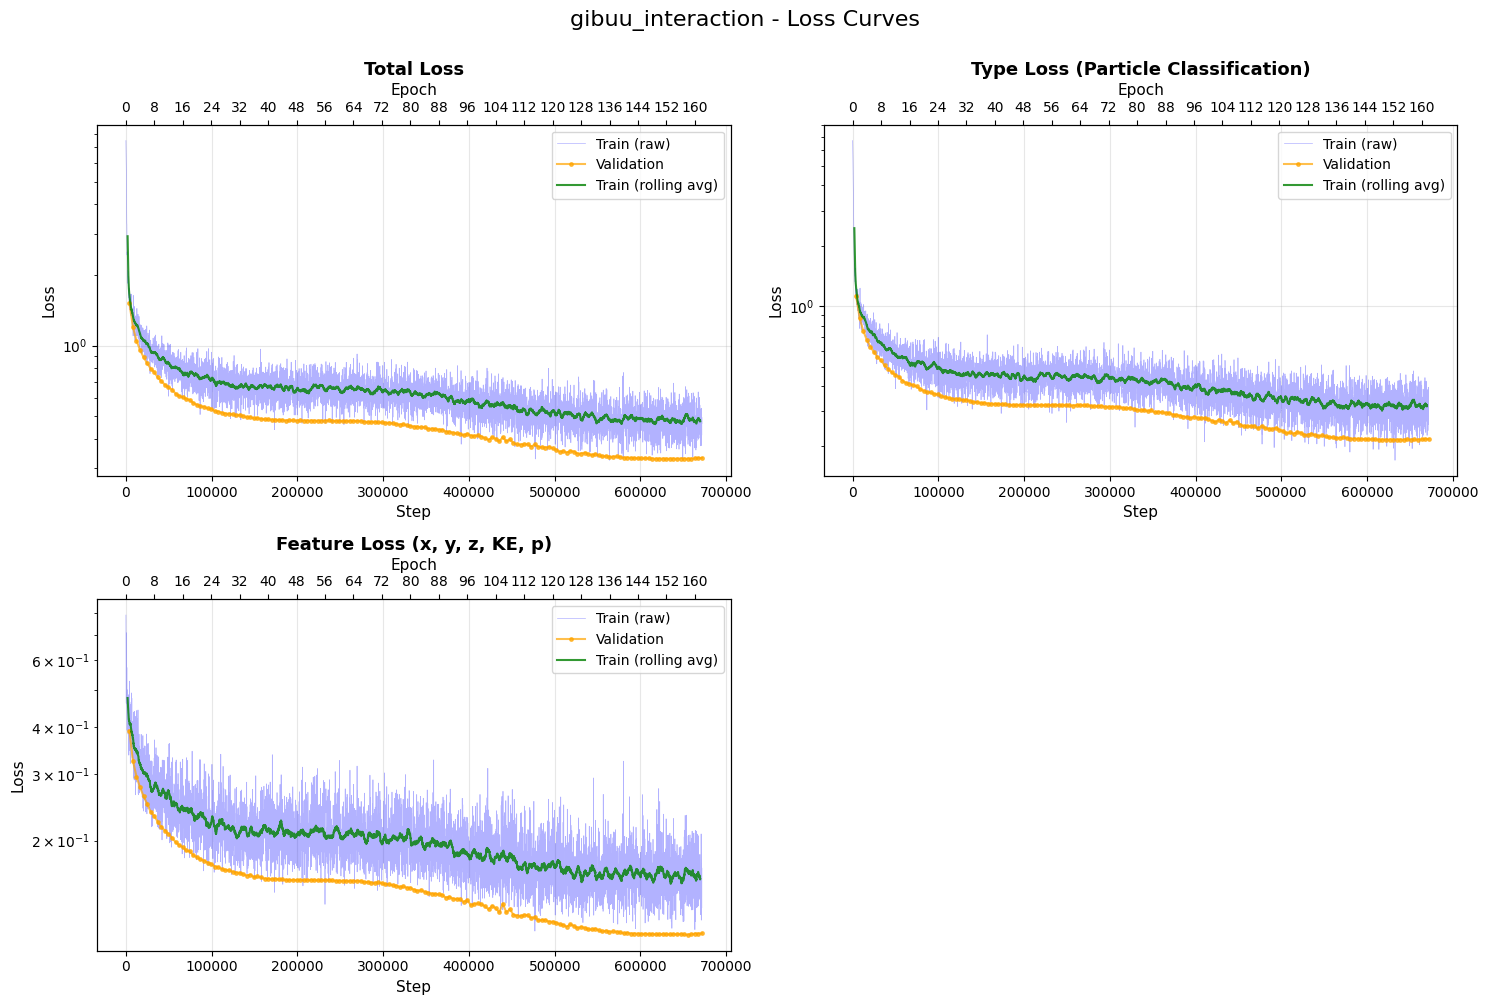

In [11]:
### Plot Loss Curves
from gibuu_transformer import plot_loss_curves
import matplotlib.pyplot as plt
import pandas as pd

EXPERIMENT_NAME = "gibuu_interaction"
COMBINE_CSV = True
if COMBINE_CSV:
    csv_idx_list = [0, 1] # modify the list
    csv_path = f"lightning_logs/{EXPERIMENT_NAME}/combined.csv"
    dfs = [pd.read_csv(f'lightning_logs/{EXPERIMENT_NAME}/version_{i}/metrics.csv') for i in csv_idx_list]
    combined = pd.concat(dfs, ignore_index=True)
    combined.to_csv(csv_path, index=False)
else:
    csv_idx = 0 # modify the index
    csv_path = f"lightning_logs/{EXPERIMENT_NAME}/version_{csv_idx}/metrics.csv"

# Option 2: Plot from combined CSV (if you've combined multiple versions)
# csv_path = f"lightning_logs/{EXPERIMENT_NAME}/combined.csv"

fig, axes = plot_loss_curves(
    csv_path=csv_path,
    mode='interaction',
    figsize=(15, 10),
    title=f'{EXPERIMENT_NAME} - Loss Curves',
    logy=True
)

if fig is not None:
    plt.show()

---

## Test

Load trained model and test predictions.

### Load Trained Model

In [ ]:
# Load best checkpoint
checkpoint_path = trainer.checkpoint_callback.best_model_path
# Or specify manually:
# checkpoint_path = "lightning_logs/gibuu_interaction/checkpoints/last.ckpt"

model_loaded = GiBUUInteractionLightning.load_from_checkpoint(checkpoint_path)
model_loaded.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_loaded.to(device)

print(f"✓ Model loaded from: {checkpoint_path}")

### Test Predictions

In [ ]:
# Get a test batch
test_batch = next(iter(val_loader))

# Move to device
test_batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in test_batch.items()}

# Predict
with torch.no_grad():
    output = model_loaded(
        test_batch['input_encoded_ids'],
        test_batch['input_particle_feats'],
        test_batch['input_padding_mask'],
        test_batch['output_encoded_ids'],
        test_batch['output_particle_feats'],
        test_batch['output_padding_mask']
    )

print("✓ Predictions made!")
print(f"\nOutput keys: {output.keys()}")
print(f"  Particle types shape: {output['particle_types'].shape}")
print(f"  Particle feats shape: {output['particle_feats'].shape}")

# Compute loss for this batch
loss_dict = gibuu_interaction_loss(output, test_batch)
print(f"\nTest loss: {loss_dict['total_loss']:.4f}")
print(f"  Type loss: {loss_dict['type_loss']:.4f}")
print(f"  Feature loss: {loss_dict['feat_loss']:.4f}")

### Helper: List Available Checkpoints

In [ ]:
# List all available checkpoints for the experiment
checkpoints = list_checkpoints(EXPERIMENT_NAME)
print(f"\nTotal: {len(checkpoints)} checkpoints")